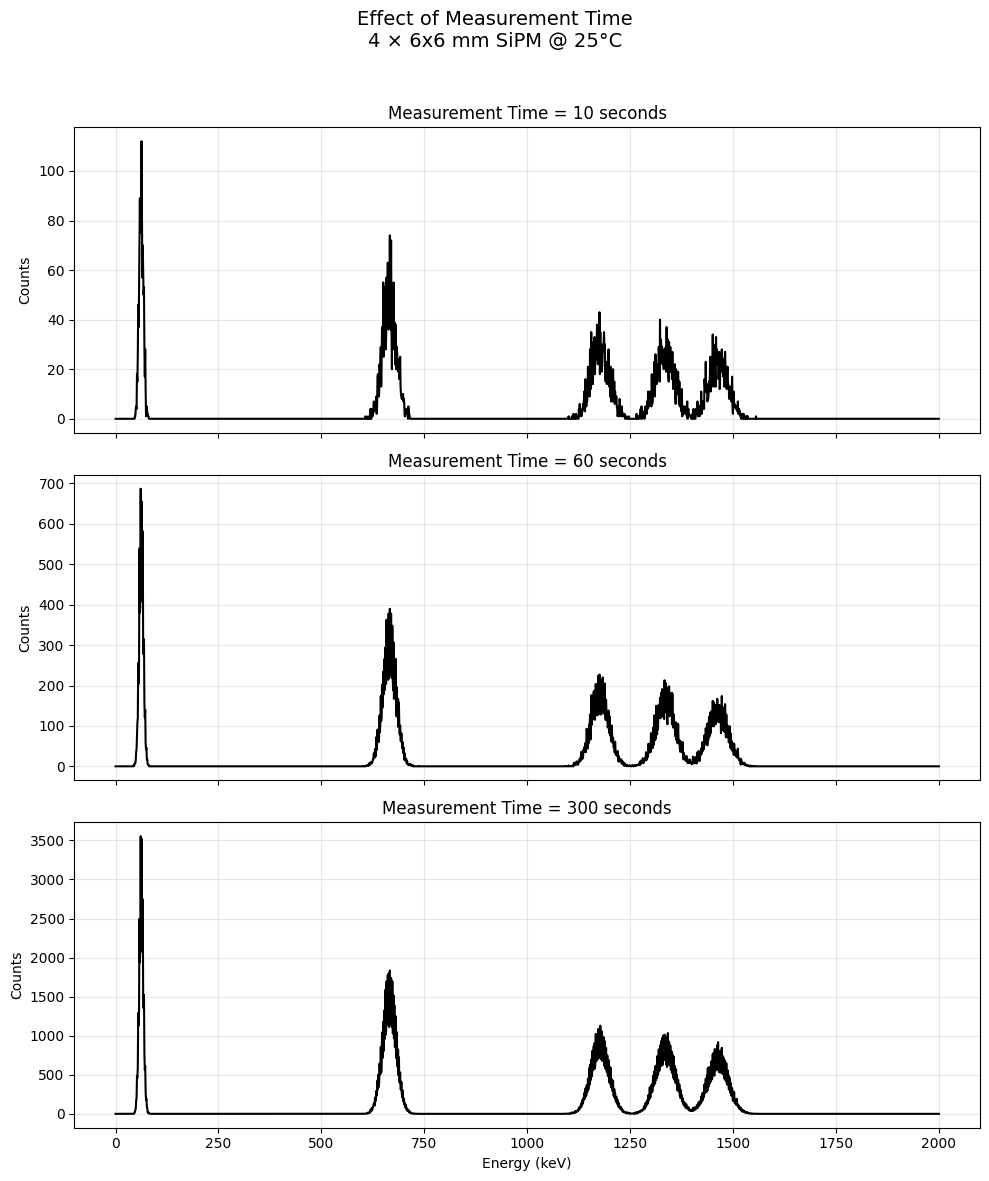

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------

Emax = 2000
bins = 2000
energy_axis = np.linspace(0, Emax, bins)

# 4 SiPM configuration
pe_per_keV = 0.59 * 4
tau = 1e-6
DCR_25 = 2e6 * 4
temperature = 25

# measurement times (seconds)
times = [10, 60, 300]

# isotopes
isotopes = [
    (59.5, 0.6),
    (662, 1.0),
    (1173, 0.8),
    (1332, 0.8),
    (1460, 0.7),
]

base_rate = 200  # events per second per intensity unit

def simulate_time_spectrum(measurement_time):
    spectrum = np.zeros(bins)

    DCR = DCR_25
    dark_mean = DCR * tau

    total_events_scale = base_rate * measurement_time

    for energy, intensity in isotopes:
        N_signal = energy * pe_per_keV
        n_events = int(total_events_scale * intensity)

        for _ in range(n_events):

            signal_pe = np.random.poisson(N_signal)
            dark_pe = np.random.poisson(dark_mean)

            total_pe = signal_pe + dark_pe
            measured_energy = total_pe / pe_per_keV

            if 0 <= measured_energy < Emax:
                bin_index = int(measured_energy / Emax * bins)
                spectrum[bin_index] += 1

    return spectrum


# ----------------------------
# Plot stacked diagrams
# ----------------------------

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for ax, t in zip(axes, times):
    spec = simulate_time_spectrum(t)
    ax.plot(energy_axis, spec, color="black")
    ax.set_title(f"Measurement Time = {t} seconds")
    ax.set_ylabel("Counts")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Energy (keV)")
fig.suptitle("Effect of Measurement Time\n4 × 6x6 mm SiPM @ 25°C", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()